<a href="https://colab.research.google.com/github/Yovana-Palencia/Mineria-De-Datos/blob/main/Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

#
# Universidad Politécnica de San Luis Potosí
## Ingeniería en Tecnologías de la Información

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRNnUMtCyJL2qB1WTgJTAwJ3JBUGAr1P9aciA&s" width="200">

---

# Proyecto: Minería de Datos
### Clasificación de Comandos de Voz mediante Redes Neuronales

**Presenta:**
### Martínez Ortíz Eduardo Antonio
**Matrícula:** 176535

### Josué Pineda Aguilar
**Matrícula:** 181662

###PALENCIA SÁNCHEZ YOVANA ISABEL
**Matrícula:** 174197

**Grupo:** 08:00 - 09:00 pm

**Fecha:** mayo de 2026

---

</div>

### Descripción del Proyecto
Este proyecto consiste en el desarrollo de un modelo de **Deep Learning** capaz de procesar señales de audio y clasificarlas en dos comandos específicos: *"Encender luz"* y *"Apagar luz"*. Se utiliza la extracción de características mediante **MFCC** y una arquitectura de red neuronal densa.

### Tecnologías Utilizadas
* **Lenguaje:** Python 3.x
* **Entorno:** Google Colab
* **Librerías Principales:** Librosa, TensorFlow/Keras, NumPy, Matplotlib.

# 1. Introducción
En el campo de la **Minería de Datos**, el procesamiento de señales de audio representa uno de los desafíos más interesantes debido a la naturaleza no estructurada de la información. Este proyecto se enfoca en el desarrollo de un sistema de reconocimiento de comandos de voz simple (*keyword spotting*) diseñado para entornos de automatización.

El objetivo principal es clasificar fragmentos de audio de corta duración para distinguir entre dos intenciones específicas: **"Encender luz"** y **"Apagar luz"**. Para lograrlo, implementamos un flujo de trabajo que abarca desde la recolección de muestras reales hasta el entrenamiento de una red neuronal artificial.


# 2. Información del Proyecto y Metodología

## 2.1 Extracción de Características (MFCC)
A diferencia de los datos tabulares tradicionales, el audio crudo contiene demasiada redundancia. Para este proyecto, transformamos las ondas sonoras en **Coeficientes Cepstrales en la Frecuencia de Mel (MFCC)**.
- **¿Por qué MFCC?**: Esta técnica procesa el audio de forma similar a como lo hace el oído humano, destacando las frecuencias que son críticas para entender el habla y descartando el ruido irrelevante.

## 2.2 El Dataset
El modelo se nutre de un dataset colaborativo compuesto por:
* **Sujetos:** 61 alumnos de la UPSLP.
* **Muestras:** 2 frases por alumno ("Encender luz" / "Apagar luz").
* **Total:** 122 registros de audio procesados y normalizados.

## 2.3 Arquitectura del Modelo
Se utiliza una red neuronal **Secuencial** (Deep Learning) con las siguientes características:
1.  **Capa de Entrada:** Aplana los coeficientes MFCC para ser procesados.
2.  **Capas Ocultas (Densas):** Capas totalmente conectadas con activación *ReLU* para aprender patrones complejos de pronunciación.
3.  **Capa de Salida:** Una única neurona con activación *Sigmoide*, ideal para clasificación binaria (0 o 1).

## 2.4 Evaluación
La eficacia del modelo no solo se mide con la precisión (*accuracy*) durante el entrenamiento, sino mediante una **"Prueba Ciega"** utilizando la voz del docente para verificar la capacidad de generalización del sistema ante locutores desconocidos.

In [ ]:
# ==========================================
# Paso 1: Importación de herramientas
# ==========================================
!pip install librosa numpy tensorflow matplotlib scikit-learn resampy

import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from sklearn.model_selection import train_test_split
import resampy
import librosa

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 2 Montar Drive si se desconectó al reiniciar
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/Librosa'

def load_data(dataset_path, n_mfcc=13, max_pad_len=40):
    labels = []
    features = []
    classes = ['apagar luz', 'encender luz']

    for i, label in enumerate(classes):
        folder_path = os.path.join(dataset_path, label)

        for file in os.listdir(folder_path):
            if file.endswith('.wav') or file.endswith('.mp3'):
                file_path = os.path.join(folder_path, file)

                # Aquí es donde se usa resampy internamente:
                audio, sr = librosa.load(file_path, res_type='kaiser_fast')

                mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)

                if (max_pad_len > mfcc.shape[1]):
                    pad_width = max_pad_len - mfcc.shape[1]
                    mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
                else:
                    mfcc = mfcc[:, :max_pad_len]

                features.append(mfcc)
                labels.append(i)

    return np.array(features), np.array(labels)

# Llamar a la función
X, y = load_data(DATASET_PATH)
X = (X - np.mean(X)) / np.std(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("¡Listo! Datos cargados y variables creadas exitosamente.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_6087/1213047547.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, res_type='kaiser_fast')
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_6087/1213047547.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, res_type='kaiser_fast')
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_6087/1213047547.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, res_type=

¡Listo! Datos cargados y variables creadas exitosamente.


/tmp/ipykernel_6087/1213047547.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, res_type='kaiser_fast')
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 250ms/step - accuracy: 0.5714 - loss: 0.8442 - val_accuracy: 0.0000e+00 - val_loss: 1.1601
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5000 - loss: 0.6949 - val_accuracy: 0.5000 - val_loss: 0.6835
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6429 - loss: 0.6562 - val_accuracy: 0.7500 - val_loss: 0.5931
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5714 - loss: 0.6541 - val_accuracy: 0.7500 - val_loss: 0.6550
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6429 - loss: 0.6017 - val_accuracy: 0.0000e+00 - val_loss: 0.8257
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5714 - loss: 0.5766 - val_accuracy: 0.0000e+00 - val_loss: 0.9859
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5000 - loss: 0.5668 - val_accuracy: 0.0000e+00 - val_loss: 1.0187
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5714 - loss: 0.5455 - val_accuracy: 0.0000e+0

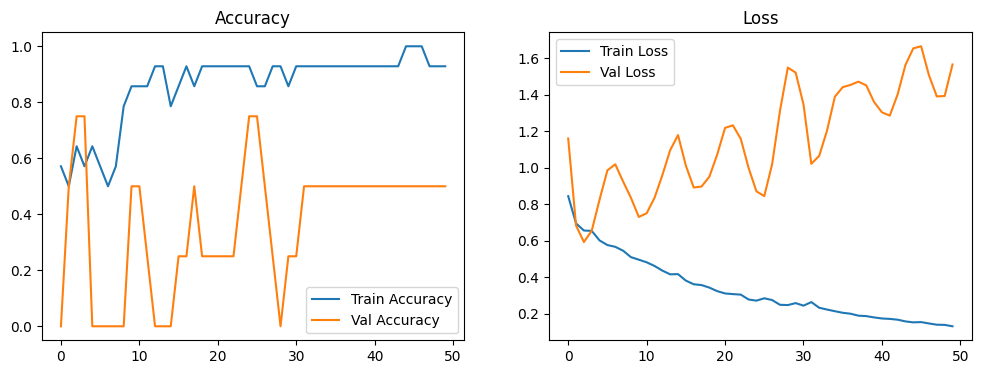

In [ ]:
# ==========================================
# Fase 3: Desarrollo del Modelo y Optimización
# ==========================================

# 3.1 Arquitectura base y 3.2 Experimentación
def build_model(layers_count=2, neurons=64):
    model = Sequential()
    # Capa de Entrada (Recibe los MFCCs)
    model.add(Input(shape=(13, 40)))
    model.add(Flatten())

    # Capas ocultas dinámicas para Tuning
    for _ in range(layers_count):
        model.add(Dense(neurons, activation='relu'))

    # Salida Sigmoide para clasificación binaria
    model.add(Dense(1, activation='sigmoid'))

    # 3.3 Configuración de Entrenamiento
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_model(layers_count=2, neurons=64)
history = model.fit(X_train, y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test))

# Graficar resultados
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
# ==========================================
# Fase 4: Evaluación y Resultados
# ==========================================

# 4.1 Simulación de salida
def predict_command(audio_path):
    # Preprocesamiento idéntico
    audio, sr = librosa.load(audio_path, res_type='kaiser_fast')
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

    # Padding
    if (40 > mfcc.shape[1]):
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, 40 - mfcc.shape[1])), mode='constant')
    else:
        mfcc = mfcc[:, :40]

    mfcc = mfcc.reshape(1, 13, 40) # Reshape para el modelo
    prediction = model.predict(mfcc)[0][0]

    if prediction > 0.5:
        return f"Luz Encendida ({prediction:.2f})"
    else:
        return f"Luz Apagada ({prediction:.2f})"

In [ ]:

# 4.2 Prueba de voz
prueba_voz = 'RUTA DE LA PRUEBA DE VOZ'
print(predict_command(prueba_voz))